# **Import Libraries**

In [1]:
# --- Standard Python Libraries ---
import copy
import math
import string
from collections import Counter

# --- Third-Party Libraries ---
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
from nltk import ngrams
from nltk.corpus import gutenberg
from nltk.corpus import stopwords

# --- NLTK Data Downloads ---
nltk.download('punkt')
nltk.download('gutenberg')



[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package gutenberg to /usr/share/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


True

In [2]:
import pandas as pd
import re
import string
from datasets import load_dataset
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

pd.set_option('display.max_colwidth', None)

# **Download Training and Testing Corpus**

In [3]:
ds = load_dataset("avsolatorio/mteb-emotion-avs_triplets")

In [4]:
ds.set_format(type='pandas')

In [5]:
df = ds['train'][:]

In [6]:
df.head()

,text,label,label_text,idx,query_idx,positive_idx,negative_idx
0,i just don t feel i have it in me to get out of bed i can will the dull throbbing of hopelessness to give way and let forth a renewed sensed of hope reflect back on my accomplishments and dig up the inner strength i ve worked so very hard to reestablish,0,sadness,0,0,8206,8560
1,i feel strongly impressed that there must be something for me to do,5,surprise,1,1,3668,12478
2,i didnt feel too needy i didnt feel too emotional,0,sadness,2,2,9880,5520
3,i anyone another lovely day today weather am running late with life generally and not done any art today yet feel deprived bit of,0,sadness,3,3,6058,1686
4,i feel im getting less and less vigorous,1,joy,4,4,4077,2374


In [7]:
df = df[['text', 'label_text']]

In [8]:
df = df.rename(columns={'label_text': 'label'})
df.head()

,text,label
0,i just don t feel i have it in me to get out of bed i can will the dull throbbing of hopelessness to give way and let forth a renewed sensed of hope reflect back on my accomplishments and dig up the inner strength i ve worked so very hard to reestablish,sadness
1,i feel strongly impressed that there must be something for me to do,surprise
2,i didnt feel too needy i didnt feel too emotional,sadness
3,i anyone another lovely day today weather am running late with life generally and not done any art today yet feel deprived bit of,sadness
4,i feel im getting less and less vigorous,joy


In [58]:
import re

def preprocess_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)   
    return text

In [84]:
df["clean_text"] = df["text"].apply(preprocess_text)
df.head()

,text,label,clean_text
0,i just don t feel i have it in me to get out of bed i can will the dull throbbing of hopelessness to give way and let forth a renewed sensed of hope reflect back on my accomplishments and dig up the inner strength i ve worked so very hard to reestablish,sadness,i just don t feel i have it in me to get out of bed i can will the dull throbbing of hopelessness to give way and let forth a renewed sensed of hope reflect back on my accomplishments and dig up the inner strength i ve worked so very hard to reestablish
1,i feel strongly impressed that there must be something for me to do,surprise,i feel strongly impressed that there must be something for me to do
2,i didnt feel too needy i didnt feel too emotional,sadness,i didnt feel too needy i didnt feel too emotional
3,i anyone another lovely day today weather am running late with life generally and not done any art today yet feel deprived bit of,sadness,i anyone another lovely day today weather am running late with life generally and not done any art today yet feel deprived bit of
4,i feel im getting less and less vigorous,joy,i feel im getting less and less vigorous


In [134]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    analyzer="word",
    ngram_range=(2,2),    
    binary=True,          
    lowercase=True      
)

le = LabelEncoder()
y = le.fit_transform(df["label"])
print(le.classes_) 

X_train, X_test, y_train, y_test = train_test_split(df["clean_text"], y, test_size=0.2, random_state=42, stratify=y)
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

X_train = X_train.toarray().astype(int)
X_test  = X_test.toarray().astype(int)


print(f"\nTotal examples: {len(df)}")
print(f"Training examples: {X_train.shape[0]}")
print(f"Training examples: {len(y_train)}")
print(f"Test examples: {X_test.shape[0]}")
print(f"Test examples: {len(y_test)}")

['anger' 'fear' 'joy' 'love' 'sadness' 'surprise']

Total examples: 16000
Training examples: 12800
Training examples: 12800
Test examples: 3200
Test examples: 3200


# Discuss
1. No, it is not the best representation for the sentences as it takes a lot of time to train and storage to use. Moreover, there many other approaches that can be better like using an efficient representation for the sparse vectors or using embedding layer that learns to reduce the error or using word2vec and others. 

In [135]:
unique, counts = np.unique(y, return_counts=True)
for label, count in zip(unique, counts):
    print(f"{le.inverse_transform([label])[0]} → {count} samples")


anger → 2159 samples
fear → 1937 samples
joy → 5362 samples
love → 1304 samples
sadness → 4666 samples
surprise → 572 samples


In [136]:
print(X_train.shape)
X_test.shape

(12800, 20000)


(3200, 20000)

In [137]:
import numpy as np

class LogisticRegressionCustom:
    def __init__(self, lr=0.1, epochs=100, reg_lambda=1e-4, batch_size=32, tol=1e-6, patience=10, verbose=False):
        self.lr = lr
        self.epochs = epochs
        self.reg_lambda = reg_lambda
        self.batch_size = batch_size
        self.tol = tol
        self.patience = patience
        self.verbose = verbose

    def sigmoid(self, z):  
        pos = z >= 0
        out = np.empty_like(z, dtype=np.float64)
        out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
        neg = ~pos
        out[neg] = np.exp(z[neg]) / (1.0 + np.exp(z[neg]))
        return out

    def fit(self, X, y):
        X = X if hasattr(X, "dot") else np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64).reshape(-1)
        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features, dtype=np.float64)
        self.bias = 0.0

        best_loss = np.inf
        patience_counter = 0
        self.is_fitted_ = True  

        for epoch in range(self.epochs):
            indices = np.random.permutation(n_samples)

            for start in range(0, n_samples, self.batch_size):
                idx = indices[start:start + self.batch_size]
                Xb = X[idx]
                yb = y[idx]

                z = Xb.dot(self.weights) + self.bias
                p = self.sigmoid(z)
                error = p - yb

                grad_w = Xb.T.dot(error) / len(yb) + self.reg_lambda * self.weights
                grad_b = np.mean(error)

                self.weights -= self.lr * grad_w
                self.bias -= self.lr * grad_b

            # optional: early stopping
            z_full = X.dot(self.weights) + self.bias
            p_full = self.sigmoid(z_full)
            loss = -np.mean(y * np.log(p_full + 1e-12) + (1 - y) * np.log(1 - p_full + 1e-12))

            if loss < best_loss - self.tol:
                best_loss = loss
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= self.patience:
                    if self.verbose:
                        print("Early stopping.")
                    return

            if self.verbose and epoch % 50 == 0:
                print(f"Epoch {epoch} Loss={loss:.5f}")


In [138]:
import numpy as np

class OneVsAllCustom:
    def __init__(self, base_classifier_class):
        self.base_classifier_class = base_classifier_class
        self.classifiers = {} 

    def fit(self, X, y):
        self.unique_labels = np.unique(y)
        for label in self.unique_labels:
            y_binary = (y == label).astype(int)

            clf = self.base_classifier_class() 
            clf.fit(X, y_binary)

            self.classifiers[label] = clf

    def predict(self, X):
        scores = []

        for label, clf in self.classifiers.items():
            score = clf.sigmoid(X.dot(clf.weights) + clf.bias)  
            scores.append(score)

        scores = np.vstack(scores).T
        best_class_indices = np.argmax(scores, axis=1)
        return self.unique_labels[best_class_indices]


In [139]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier


In [140]:
clf   = OneVsAllCustom(LogisticRegressionCustom)

clf.fit(X_train, y_train)

In [141]:
ok    = OneVsRestClassifier(LogisticRegression())
ok.fit(X_train, y_train)

OneVsRestClassifier(estimator=LogisticRegression())

In [142]:
ok2   = OneVsRestClassifier(SGDClassifier()) 
ok2.fit(X_train, y_train)

OneVsRestClassifier(estimator=SGDClassifier())

In [143]:
import numpy as np
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

def confusion_matrix_custom(predicts, labels):
    n_classes = len(np.unique(labels))
    cm = np.zeros((n_classes, n_classes), dtype=int)
    precision_vector = np.zeros(n_classes)
    recall_vector = np.zeros(n_classes)
    f1_vector = np.zeros(n_classes)

    for i in range(n_classes):
        for j in range(n_classes):
            cm[i][j] = np.sum((predicts == i) & (labels == j))

    with np.errstate(divide='ignore', invalid='ignore'): 
        precision_vector = np.diag(cm) / cm.sum(axis=0)
        recall_vector = np.diag(cm) / cm.sum(axis=1)
        f1_vector = 2 * precision_vector * recall_vector / (precision_vector + recall_vector)

    precision = np.nan_to_num(precision_vector).mean()
    recall = np.nan_to_num(recall_vector).mean()
    f1 = np.nan_to_num(f1_vector).mean()

    return cm, precision, recall, f1


Custom Metrics - Custom Model
Precision: 0.4512889156582726
Recall: 0.7346618465939135
F1: 0.4979849396728318
Confusion Matrix:
 [[156   9  13   4  19   1]
 [ 14 167   7   5   7  13]
 [154 109 873 133 244  47]
 [  2   5   7  55   2   2]
 [106  97 172  64 660  31]
 [  0   0   0   0   1  21]]


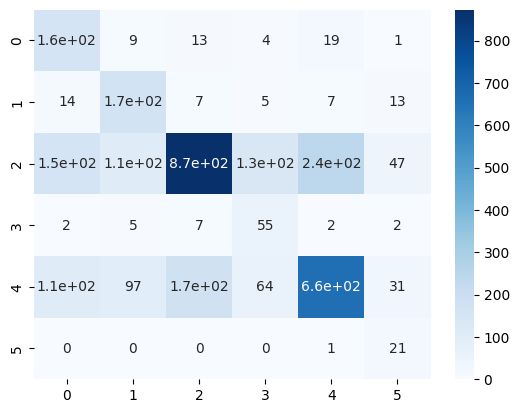

In [101]:
cm_custom, p_custom, r_custom, f1_custom = confusion_matrix_custom(clf.predict(X_test), y_test)
print("Custom Metrics - Custom Model")
sns.heatmap(cm_custom, annot=True, cmap='Blues')
print("Precision:", p_custom)
print("Recall:", r_custom)
print("F1:", f1_custom)
print("Confusion Matrix:\n", cm_custom)


In [82]:
# ok2.predict(X_test)

Custom Metrics - Custom Model
Precision: 0.45659891355631554
Recall: 0.7388931252508488
F1: 0.504145011744293
Confusion Matrix:
 [[152   9  12   5  14   3]
 [ 11 170   5   5   7  13]
 [154 115 888 141 240  46]
 [  1   4   7  53   2   2]
 [114  88 160  57 669  28]
 [  0   1   0   0   1  23]]


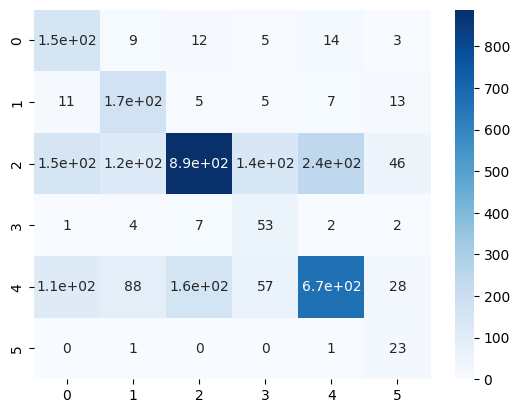

In [144]:
cm_custom, p_custom, r_custom, f1_custom = confusion_matrix_custom(clf.predict(X_test), y_test)
print("Custom Metrics - Custom Model")
sns.heatmap(cm_custom, annot=True, cmap='Blues')
print("Precision:", p_custom)
print("Recall:", r_custom)
print("F1:", f1_custom)
print("Confusion Matrix:\n", cm_custom)

Custom Metrics - Sklearn Logistic Regression Model
Precision: 0.516272495705497
Recall: 0.710448373005733
F1: 0.5644570838003459
Confusion Matrix:
 [[207  15  21   5  26   4]
 [ 13 202  13   5   8  15]
 [111  88 872 118 210  38]
 [  3   4  15  78   5   2]
 [ 98  71 150  55 683  27]
 [  0   7   1   0   1  29]]


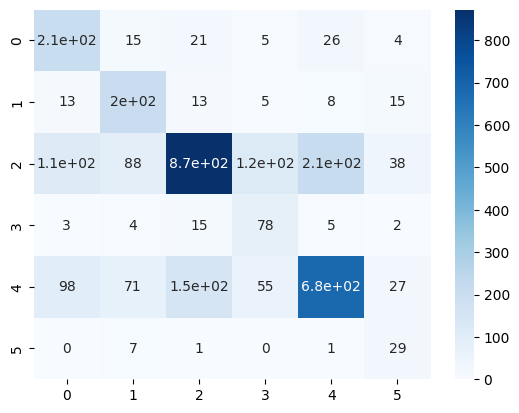

In [145]:
cm_custom, p_custom, r_custom, f1_custom = confusion_matrix_custom(ok.predict(X_test), y_test)
print("Custom Metrics - Sklearn Logistic Regression Model")
sns.heatmap(cm_custom, annot=True, cmap='Blues')
print("Precision:", p_custom)
print("Recall:", r_custom)
print("F1:", f1_custom)
print("Confusion Matrix:\n", cm_custom)


Custom Metrics - Sklearn SGD Model
Precision: 0.5835336000425204
Recall: 0.6586739384947345
F1: 0.6123077101176668
Confusion Matrix:
 [[241  25  50  11  55   5]
 [ 17 231  38   8  27  16]
 [ 74  51 780  81 151  20]
 [  9  10  34 112  16   5]
 [ 91  60 166  47 680  16]
 [  0  10   4   2   4  53]]


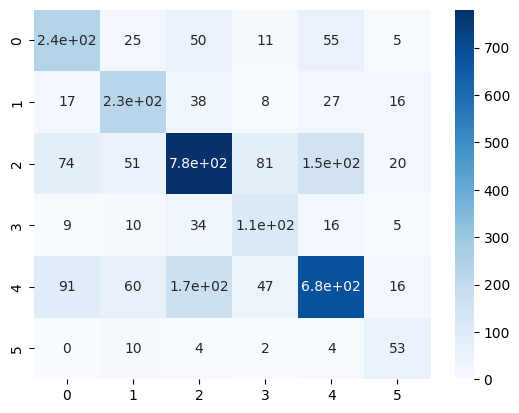

In [146]:
cm_custom, p_custom, r_custom, f1_custom = confusion_matrix_custom(ok2.predict(X_test), y_test)
print("Custom Metrics - Sklearn SGD Model")
sns.heatmap(cm_custom, annot=True, cmap='Blues')
print("Precision:", p_custom)
print("Recall:", r_custom)
print("F1:", f1_custom)
print("Confusion Matrix:\n", cm_custom)


Sklearn Metrics - Custom Model
Precision: 0.45659891355631554
Recall: 0.7388931252508488
F1: 0.504145011744293
Confusion Matrix:


<Axes: >

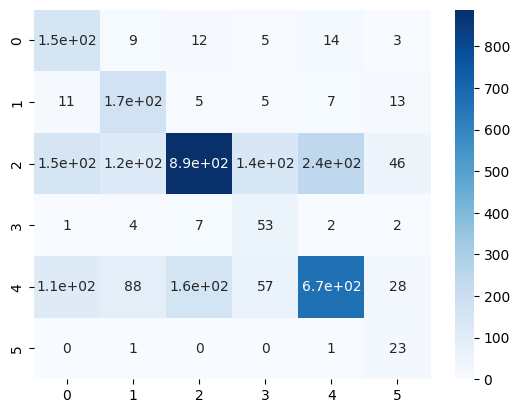

In [147]:
cm_sklearn = confusion_matrix(clf.predict(X_test), y_test)
print("Sklearn Metrics - Custom Model")
print("Precision:", precision_score(clf.predict(X_test), y_test, average='macro'))
print("Recall:", recall_score(clf.predict(X_test), y_test, average='macro'))
print("F1:", f1_score(clf.predict(X_test), y_test, average='macro'))
print("Confusion Matrix:")
sns.heatmap(cm_sklearn, annot=True, cmap='Blues')



Sklearn Metrics - Sklearn Logistic Regression Model
Precision: 0.516272495705497
Recall: 0.710448373005733
F1: 0.5644570838003459
Confusion Matrix:


<Axes: >

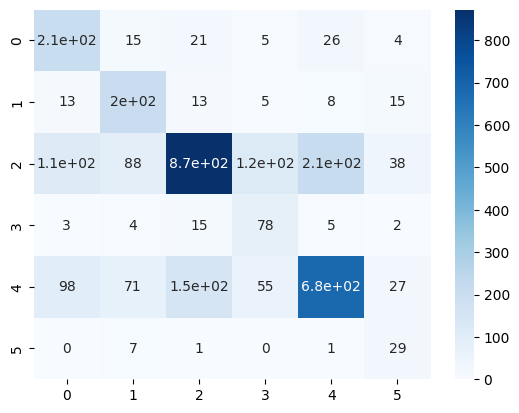

In [148]:
cm_sklearn = confusion_matrix(ok.predict(X_test), y_test)
print("Sklearn Metrics - Sklearn Logistic Regression Model")
print("Precision:", precision_score(ok.predict(X_test), y_test, average='macro'))
print("Recall:", recall_score(ok.predict(X_test), y_test, average='macro'))
print("F1:", f1_score(ok.predict(X_test), y_test, average='macro'))
print("Confusion Matrix:")
sns.heatmap(cm_sklearn, annot=True, cmap='Blues')



Sklearn Metrics - Sklearn SGD Model
Precision: 0.5835336000425204
Recall: 0.6586739384947345
F1: 0.6123077101176668
Confusion Matrix:


<Axes: >

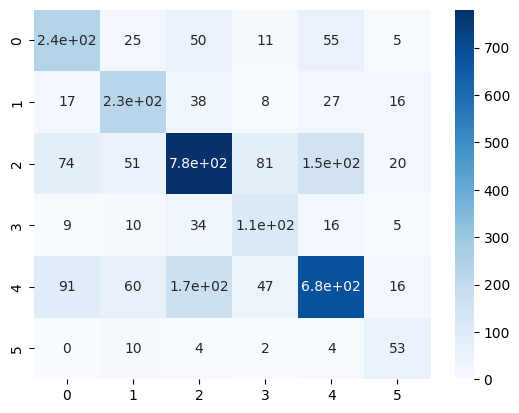

In [149]:
cm_sklearn = confusion_matrix(ok2.predict(X_test), y_test)
print("Sklearn Metrics - Sklearn SGD Model")
print("Precision:", precision_score(ok2.predict(X_test), y_test, average='macro'))
print("Recall:", recall_score(ok2.predict(X_test), y_test, average='macro'))
print("F1:", f1_score(ok2.predict(X_test), y_test, average='macro'))
print("Confusion Matrix:")
sns.heatmap(cm_sklearn, annot=True, cmap='Blues')



# Discuss

1. SGD performs better than others. The reason of this is the sparse vectors in the features which takes a lot of storage and time to train on by using SGD is not training on all dataset and on some of it only not all of it.
2. Logestic Regression is similar to our implemention in the results. However, we can slightly change the implementation to be like SGD.